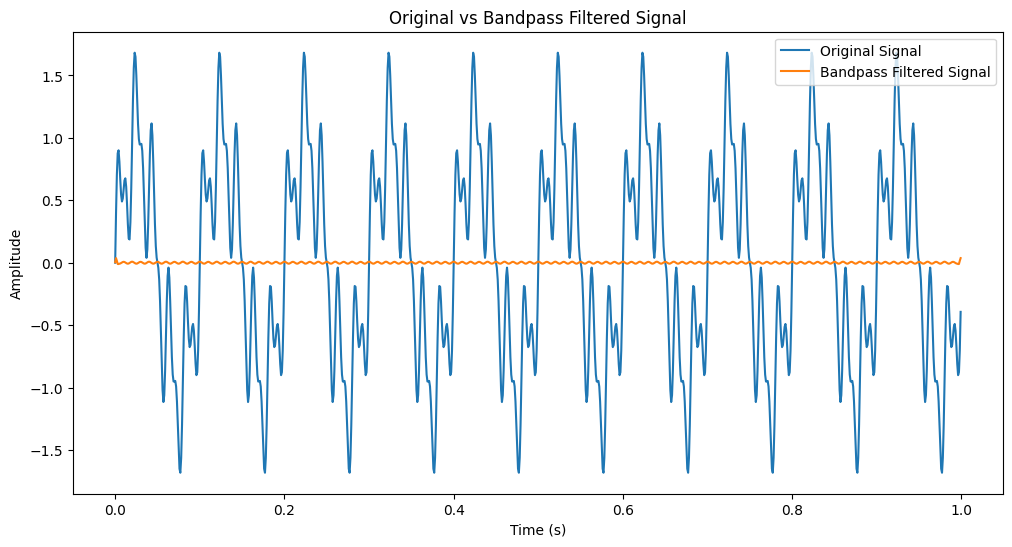

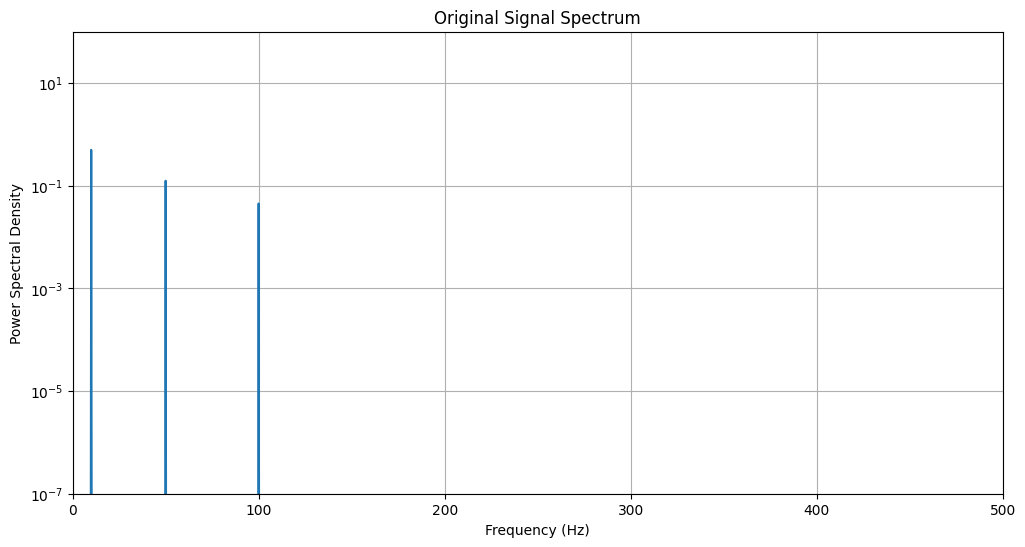

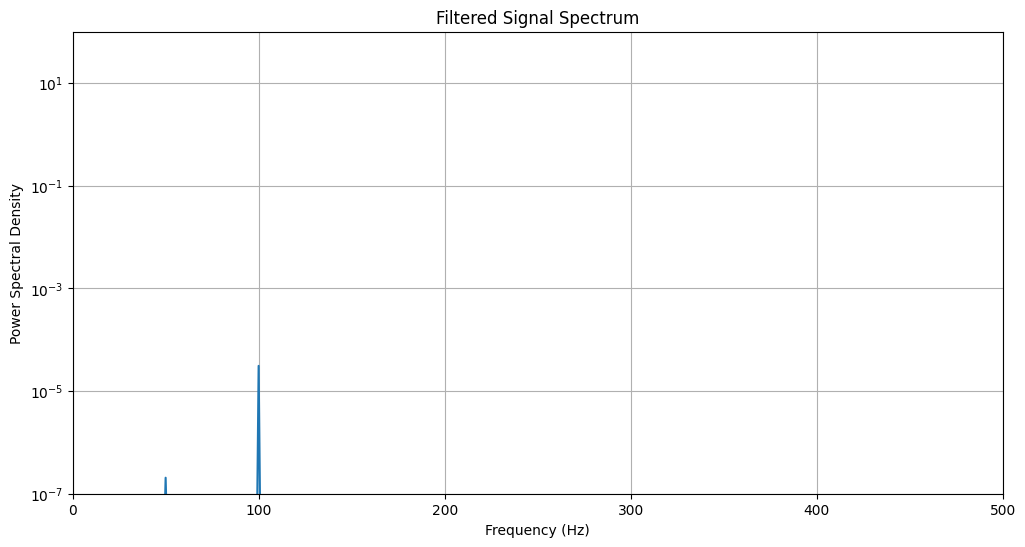

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp 

def apply_filter(signal, filter_kernel):
    filtered_signal = np.convolve(signal, filter_kernel, mode='same')
    return filtered_signal

def create_bandpass_filter(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = sp.signal.butter(order, [low, high], btype='bandpass')
    return b

# 创建一个示例信号
fs = 1000  # 采样频率
t = np.linspace(0, 1, fs, endpoint=False)
# 包含10Hz, 50Hz和100Hz的成分
signal = np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 50 * t) + 0.3 * np.sin(2 * np.pi * 100 * t)

# 创建带通滤波器 (40-60 Hz)
bandpass_filter = create_bandpass_filter(30, highcut=200, fs=fs)

# 应用滤波器
filtered_signal = apply_filter(signal, bandpass_filter)

# 绘制原始信号和滤波后的信号
plt.figure(figsize=(12, 6))
plt.plot(t, signal, label='Original Signal')
plt.plot(t, filtered_signal, label='Bandpass Filtered Signal')
plt.legend()
plt.title('Original vs Bandpass Filtered Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# 计算并绘制频谱
def plot_spectrum(signal, fs, title):
    f, Pxx = sp.signal.periodogram(signal, fs)
    plt.figure(figsize=(12, 6))
    plt.semilogy(f, Pxx)
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power Spectral Density')
    plt.ylim([1e-7, 1e2])
    plt.xlim([0, fs/2])
    plt.grid(True)

plot_spectrum(signal, fs, 'Original Signal Spectrum')
plot_spectrum(filtered_signal, fs, 'Filtered Signal Spectrum')
plt.show()